## 1. Importaciones

In [12]:
from pathlib import Path
import platform
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import sklearn

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")

SEED = 42
pd.set_option("display.max_colwidth", 120) 
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
SEED = RANDOM_STATE  # alias para compatibilidad

## 2. Carga de datos

In [13]:
PROYECTO_DIR = Path(".").resolve()
TRAIN_PATH = PROYECTO_DIR / "train.csv"
EVAL_PATH = PROYECTO_DIR / "eval.csv"
OUTPUT_DIR = PROYECTO_DIR / "outputs_parte1"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROYECTO_DIR:", PROYECTO_DIR)

train_df = pd.read_csv(TRAIN_PATH)
eval_df = pd.read_csv(EVAL_PATH)

print("train_df shape:", train_df.shape)
print("eval_df shape:", eval_df.shape)

display(train_df.head())
display(eval_df.head())

PROYECTO_DIR: C:\Users\juand\Downloads\Proyecto_ML
train_df shape: (31403, 2)
eval_df shape: (3490, 2)


,text,decade
0,"\r\nHonorarias ¡jubiladas. 57 \r\ndit.ad Pontem de poreft.Proreg.118,3, $.9.M.-70 \r\npag.4.1. 3 Ste ph.Gratian. dif...",164
1,"gone. Sus amigos , sus clientes, todo \r\ncuanto le rodea le prueban que es hom- \r\nbre de mucha importancia. Si ve...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan feratormentados, e \r\nante quien,e quie preguntasles deuan hazer mie...",157
3,"Caistro el M a y o r a i .] Del apellido de Cañroíe \r\nvalió Don Luis enefta. Metáfora, para el ...",163
4,"\r\nlos que panden macho ; y \r\notros en la fu ña abundan¬ \r\ncia , íiempre viuen como \r\nmendigos....",166


,id,text
0,0,"P. Si en efta convocación trato folamente de comunicarles los artículos arregla- \r\ndos, y firmados, o ..."
1,1,"«Muy santo Padre : Ayer escribiá don Juan Man- \r\ny rique que dijese á vuestra Santidad, ó le escribie- \r\n»se, en..."
2,2,"Recibo, otorgado por Diego Gracián a favor de Jerónimo Zurita, de un libro de Casiodoro, titulado \r\nDe Amicitia et..."
3,3,"6. Los Samaritanos no admitían por \r\nEfcrituras Canónicas fino los cinco Libros \r\nde Moyfes, tfloes, ..."
4,4,ü«mi yofacaremisoiiejasfilasmaí \r\nI nosodlosrt no confeti tire q mas fe las co* \r\n( mauXomeímo oíjeeiie...


In [14]:
required_train_cols = {"text", "decade"}
required_eval_cols = {"id", "text"}

if not required_train_cols.issubset(train_df.columns):
    raise ValueError(f"train.csv debe contener columnas {required_train_cols}")
if not required_eval_cols.issubset(eval_df.columns):
    raise ValueError(f"eval.csv debe contener columnas {required_eval_cols}")

print("Columnas train:", list(train_df.columns))
print("Columnas eval:", list(eval_df.columns))

print("Nulos en train:")
display(train_df.isnull().sum().to_frame("nulls"))
print("Nulos en eval:")
display(eval_df.isnull().sum().to_frame("nulls"))

dup_rows_train = train_df.duplicated().sum()
dup_rows_eval = eval_df.duplicated().sum()
dup_text_train = train_df["text"].duplicated().sum()

print(f"Filas duplicadas en train: {dup_rows_train}")
print(f"Filas duplicadas en eval: {dup_rows_eval}")
print(f"Textos duplicados en train: {dup_text_train}")

conflictos_textos = (
    train_df.groupby("text")["decade"].nunique().reset_index(name="n_labels").query("n_labels > 1")
)

print("Textos iguales con etiquetas distintas:", len(conflictos_textos))

print("\nNumero de clases:", train_df["decade"].nunique())
print("Rango de decadas:", train_df["decade"].min(), "-", train_df["decade"].max())

Columnas train: ['text', 'decade']
Columnas eval: ['id', 'text']
Nulos en train:


,nulls
text,0
decade,0


Nulos en eval:


,nulls
id,0
text,0


Filas duplicadas en train: 34
Filas duplicadas en eval: 0
Textos duplicados en train: 51
Textos iguales con etiquetas distintas: 12

Numero de clases: 39
Rango de decadas: 150 - 188


Se realizó una revisión básica del conjunto de entrenamiento y evaluación:
- verificación de columnas requeridas,
- inspección de valores nulos,
- revisión de duplicados exactos y textos repetidos,
- revisión del número de clases y su rango.

En esta versión no se eliminaron duplicados automáticamente, porque existen textos repetidos y algunos casos con etiquetas distintas; removerlos sin criterio adicional podría alterar el problema original. La decisión metodológica fue conservar el dataset original y documentar esta condición.

## 3. Exploración y preparación de datos

In [15]:
x_train = train_df[["text"]].fillna("")
y_train = train_df["decade"].astype(int)

x_eval = eval_df[["text"]].fillna("")
eval_ids = eval_df["id"]

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_eval:", x_eval.shape)

x_train: (31403, 1)
y_train: (31403,)
x_eval: (3490, 1)


In [16]:
import re

def clean_text(text: str) -> str:
    """Limpieza mínima: solo normaliza espacios y saltos de línea.
    Se preserva la ortografía arcaica y el ruido de OCR porque son señal temporal."""
    text = re.sub(r'[\n\r\t]+', ' ', text)
    text = re.sub(r' {2,}', ' ', text)
    return text.strip()

train_df['text'] = train_df['text'].fillna('').apply(clean_text)
eval_df['text']  = eval_df['text'].fillna('').apply(clean_text)

# Actualizar x_train y x_eval con texto limpio
x_train = train_df[['text']].fillna('')
x_eval  = eval_df[['text']].fillna('')

print('Limpieza completada ✓')
print('Ejemplo:')
print(train_df['text'].iloc[0][:200])


Limpieza completada ✓
Ejemplo:
Honorarias ¡jubiladas. 57 dit.ad Pontem de poreft.Proreg.118,3, $.9.M.-70 pag.4.1. 3 Ste ph.Gratian. difcept.291, áqu len nes parece que aísilte, O ayuda Calsiodoro lib,6.epuft.s 2.Donde * llama Oclos


In [17]:
counts = pd.Series(y_train).value_counts().sort_index()
print(f'Clases    : {len(counts)} décadas ({y_train.min()}–{y_train.max()})')
print(f'Por clase : min={counts.min()}, max={counts.max()}, media={counts.mean():.0f}')
print('→ Dataset balanceado, no se necesita class_weight')


Clases    : 39 décadas (150–188)
Por clase : min=754, max=848, media=805
→ Dataset balanceado, no se necesita class_weight


## 4. Preprocesamiento

In [18]:
def build_preprocessor(
    word_ngram_range=(1, 2),
    char_ngram_range=(3, 5),
    word_min_df=3,
    char_min_df=3,
    word_max_features=120_000,
    char_max_features=180_000,
    use_word=True,
    use_char=True,
):
    transformers = []
    
    if use_word:
        transformers.append(
            (
                "word_tfidf",
                TfidfVectorizer(
                    strip_accents="unicode",
                    lowercase=True,
                    ngram_range=word_ngram_range,
                    min_df=word_min_df,
                    max_df=0.95,
                    sublinear_tf=True,
                    max_features=word_max_features,
                ),
                "text",
            )
        )
    if use_char:
        transformers.append(
            (
                "char_tfidf",
                TfidfVectorizer(
                    strip_accents="unicode",
                    lowercase=True,
                    analyzer="char_wb",
                    ngram_range=char_ngram_range,
                    min_df=char_min_df,
                    sublinear_tf=True,
                    max_features=char_max_features,
                ),
                "text",
            )
        )
        
    return ColumnTransformer(
        transformers=transformers, 
        remainder="drop"
    )

def make_pipeline(model, **prep_kwargs):
    return Pipeline([
        ("features", build_preprocessor(**prep_kwargs)),
        ("model", model),
    ])
    
def fit_export_submission(models_dict, cv_results_df, submission_tag):
    best_model_name = cv_results_df.loc[0, "model"]
    best_model = models_dict[best_model_name]
    
    best_model.fit(x_train, y_train)
    
    model_path = OUTPUT_DIR / f"modelo_{submission_tag}.joblib"
    joblib.dump(best_model, model_path)
    
    preds = best_model.predict(x_eval)
    submission = pd.DataFrame({
        "id": eval_ids, 
        "answer": preds.astype(int)
    })
    
    submission_path = OUTPUT_DIR / f"{submission_tag}.csv"
    submission.to_csv(submission_path, index=False)
    
    print("Mejor modelo:", best_model_name)
    print("Modelo guardado en :", model_path) 
    print("Submission guardada:", submission_path)
    print("Filas:", len(submission))

    display(submission.head())

    return best_model_name, model_path, submission_path
    
    
def build_models_submission_1():
    return {
        "LinearSVC_C1.5": make_pipeline(LinearSVC(C=1.5, random_state=SEED)),
        "LinearSVC_C2.5": make_pipeline(LinearSVC(C=2.5, random_state=SEED)),
        "LogReg_C3": make_pipeline(LogisticRegression(C=3.0, max_iter=3000, random_state=SEED)),
        "ComplementNB_a025": make_pipeline(ComplementNB(alpha=0.25)),
    }
    
def build_models_submission_2():
    return {
        "LogReg_C1" : make_pipeline(LogisticRegression(C=1.0, max_iter=3000, random_state=SEED)),
        "LogReg_C3" : make_pipeline(LogisticRegression(C=3.0, max_iter=3000, random_state=SEED)),
        "LogReg_C5" : make_pipeline(LogisticRegression(C=5.0, max_iter=3000, random_state=SEED)),
        "LogReg_C7" : make_pipeline(LogisticRegression(C=7.0, max_iter=3000, random_state=SEED)),
    }

In [19]:
def run_experiments(models_dict, experiment_name):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    rows = []
    
    print(f"Ejecutando experimentos: {experiment_name}")
    
    for name ,model in models_dict.items():
        t0 = time.time()
        
        cv_results = cross_validate(
            model,
            x_train,
            y_train,
            cv=cv,
            scoring="accuracy",
            n_jobs=1,
            return_train_score=False,
        )
        
        elapsed = time.time() - t0
        
        rows.append({
            "experiment": experiment_name,
            "model": name,
            "cv_accuracy_mean": float(cv_results["test_score"].mean()),
            "cv_accuracy_std": float(cv_results["test_score"].std()),
            "elapsed_sec": round(elapsed, 1),
        })
        
        print(
            f"{name}: "
            f"{rows[-1]["cv_accuracy_mean"]:.5f} "
            f"+/- {rows[-1]["cv_accuracy_std"]:.5f} "
            f"({elapsed:.1f}s)"
        )
    
    results = (
        pd.DataFrame(rows)
        .sort_values("cv_accuracy_mean", ascending=False)
        .reset_index(drop=True)
    )
    
    out_path = OUTPUT_DIR / f"cv_resultados_{experiment_name}.csv"
    results.to_csv(out_path, index=False)
    
    print(f"Resultados guardados en: {out_path}")
    display(results)
    
    return results

## 5. Submission 1 — Baseline

In [9]:
models_s1 = build_models_submission_1()
cv_results_s1 = run_experiments(models_s1, "submission_01_baseline")

Ejecutando experimentos: submission_01_baseline


KeyboardInterrupt: 

In [ ]:
best_model_name_s1 = cv_results_s1.loc[0, "model"]
best_model_s1 =models_s1[best_model_name_s1]

best_model_s1.fit(x_train, y_train)

model_path_s1 = OUTPUT_DIR / f"modelo_submission_01_baseline.joblib"
joblib.dump(best_model_s1, model_path_s1)

preds_s1 = best_model_s1.predict(x_eval)
submission_s1 = pd.DataFrame({
    "id": eval_ids,
    "answer": preds_s1.astype(int),
})

submission_path_s1 = OUTPUT_DIR / "submission_01_baseline.csv"
submission_s1.to_csv(submission_path_s1, index=False)

print("Modelo Submission 1:", best_model_name_s1)
print("Modelo guardado en :", model_path_s1)
print("Submission guardada:", submission_path_s1)
print("Columnas:", list(submission_s1.columns))
print("Filas:", len(submission_s1))

display(submission_s1.head())

NameError: name 'cv_results_s1' is not defined

## 6. Submission 2 — Ajuste de LogReg

In [ ]:
models_s2 = build_models_submission_2()
cv_results_s2 = run_experiments(models_s2, "submission_02_logreg_tuning")

Ejecutando experimentos: submission_02_logreg_tuning
LogReg_C1: 0.25498 +/- 0.00433 (1092.4s)
LogReg_C3: 0.25998 +/- 0.00294 (1406.7s)
LogReg_C5: 0.25918 +/- 0.00311 (1434.1s)
LogReg_C7: 0.25940 +/- 0.00304 (1612.4s)
Resultados guardados en: C:\ANDES\BI\MaterialDeClase-ISIS-2611\Proyecto\outputs_parte1\cv_resultados_submission_02_logreg_tuning.csv


,experiment,model,cv_accuracy_mean,cv_accuracy_std,elapsed_sec
0,submission_02_logreg_tuning,LogReg_C3,0.259975,0.002940,1406.7
1,submission_02_logreg_tuning,LogReg_C7,0.259402,0.003039,1612.4
2,submission_02_logreg_tuning,LogReg_C5,0.259179,0.003114,1434.1
3,submission_02_logreg_tuning,LogReg_C1,0.254976,0.004330,1092.4


In [ ]:
best_model_name_s2 = cv_results_s2.loc[0, "model"]
best_model_s2 = models_s2[best_model_name_s2]

best_model_s2.fit(x_train, y_train)

model_path_s2 = OUTPUT_DIR / f"modelo_submission_02_logreg_tuning.joblib"
joblib.dump(best_model_s2, model_path_s2)

preds_s2 = best_model_s2.predict(x_eval)
submission_s2 = pd.DataFrame({
    "id": eval_ids,
    "answer": preds_s2.astype(int),
})

submission_path_s2 = OUTPUT_DIR / "submission_02_logreg_tuning.csv"
submission_s2.to_csv(submission_path_s2, index=False)

print("Modelo Submission 2:", best_model_name_s2)
print("Modelo guardado en :", model_path_s2)
print("Submission guardada:", submission_path_s2)
print("Columnas:", list(submission_s2.columns))
print("Filas:", len(submission_s2))

display(submission_s2.head())

Modelo Submission 2: LogReg_C3
Modelo guardado en : C:\ANDES\BI\MaterialDeClase-ISIS-2611\Proyecto\outputs_parte1\modelo_submission_02_logreg_tuning.joblib
Submission guardada: C:\ANDES\BI\MaterialDeClase-ISIS-2611\Proyecto\outputs_parte1\submission_02_logreg_tuning.csv
Columnas: ['id', 'answer']
Filas: 3490


,id,answer
0,0,173
1,1,187
2,2,150
3,3,172
4,4,153


## 7. Submission 3 — Ajuste de features

In [ ]:
def build_models_submission_3():
    return {
        "LogReg_C3_word12_char36": make_pipeline(
            LogisticRegression(C=3.0, max_iter=3000, random_state=SEED),
            word_ngram_range=(1, 2),
            char_ngram_range=(3, 6),
            word_max_features=120_000,
            char_max_features=240_000,
        ),
        "LogReg_C3_word13_char35": make_pipeline(
            LogisticRegression(C=3.0, max_iter=3000, random_state=SEED),
            word_ngram_range=(1, 3),
            char_ngram_range=(3, 5),
            word_max_features=160_000,
            char_max_features=240_000,
        ),
        
    }

In [ ]:
models_s3 = build_models_submission_3()
cv_results_s3 = run_experiments(models_s3, "submission_03_feature_tuning")

Ejecutando experimentos: submission_03_feature_tuning
LogReg_C3_word12_char36: 0.25676 +/- 0.00276 (1679.0s)
LogReg_C3_word13_char35: 0.26077 +/- 0.00303 (1675.5s)
Resultados guardados en: C:\ANDES\BI\MaterialDeClase-ISIS-2611\Proyecto\outputs_parte1\cv_resultados_submission_03_feature_tuning.csv


,experiment,model,cv_accuracy_mean,cv_accuracy_std,elapsed_sec
0,submission_03_feature_tuning,LogReg_C3_word13_char35,0.260771,0.003034,1675.5
1,submission_03_feature_tuning,LogReg_C3_word12_char36,0.256759,0.002764,1679.0


In [ ]:
best_model_name_s3, model_path_s3, submission_path_s3 = fit_export_submission(
    models_s3,
    cv_results_s3,
    "submission_03_feature_tuning"
)

Mejor modelo: LogReg_C3_word13_char35
Modelo guardado en : C:\ANDES\BI\MaterialDeClase-ISIS-2611\Proyecto\outputs_parte1\modelo_submission_03_feature_tuning.joblib
Submission guardada: C:\ANDES\BI\MaterialDeClase-ISIS-2611\Proyecto\outputs_parte1\submission_03_feature_tuning.csv
Filas: 3490


,id,answer
0,0,173
1,1,188
2,2,150
3,3,172
4,4,153


## 8. Submission 4 — LinearSVC con features

In [ ]:
def build_models_submission_4():
    return {
        "LinearSVC_C1.5_word12_char36": make_pipeline(
            LinearSVC(C=1.5, random_state=SEED),
            word_ngram_range=(1, 2),
            char_ngram_range=(3, 6),
            word_max_features=120_000,
            char_max_features=240_000,
        ),
        "LinearSVC_C2_word13_char36": make_pipeline(
            LinearSVC(C=2.0, random_state=SEED),
            word_ngram_range=(1, 3),
            char_ngram_range=(3, 6),
            word_max_features=160_000,
            char_max_features=240_000,
            
        ),
    }

In [ ]:
models_s4 = build_models_submission_4()
cv_results_s4 = run_experiments(models_s4, "submission_04_linsvc_features")

Ejecutando experimentos: submission_04_linsvc_features
LinearSVC_C1.5_word12_char36: 0.25144 +/- 0.00284 (499.3s)
LinearSVC_C2_word13_char36: 0.25131 +/- 0.00244 (592.8s)
Resultados guardados en: C:\ANDES\BI\MaterialDeClase-ISIS-2611\Proyecto\outputs_parte1\cv_resultados_submission_04_linsvc_features.csv


,experiment,model,cv_accuracy_mean,cv_accuracy_std,elapsed_sec
0,submission_04_linsvc_features,LinearSVC_C1.5_word12_char36,0.251441,0.002840,499.3
1,submission_04_linsvc_features,LinearSVC_C2_word13_char36,0.251314,0.002444,592.8


In [ ]:
best_model_name_s4, model_path_s4, submission_path_s4 = fit_export_submission(
    models_s4,
    cv_results_s4,
    "submission_04_linsvc_features"
)

Mejor modelo: LinearSVC_C1.5_word12_char36
Modelo guardado en : C:\ANDES\BI\MaterialDeClase-ISIS-2611\Proyecto\outputs_parte1\modelo_submission_04_linsvc_features.joblib
Submission guardada: C:\ANDES\BI\MaterialDeClase-ISIS-2611\Proyecto\outputs_parte1\submission_04_linsvc_features.csv
Filas: 3490


,id,answer
0,0,181
1,1,187
2,2,150
3,3,172
4,4,153


## 9. Submission 5 — Solo char_wb

In [ ]:
def build_models_submission_5():
    return {
        "LogReg_C3_char_only_36": make_pipeline(
            LogisticRegression(C=3.0, max_iter=3000, random_state=SEED),
            use_word=False,
            use_char=True,
            char_ngram_range=(3, 6),
            char_min_df=2,
            char_max_features=300_000,
        ),
        "LinearSVC_1.5_char_only_36": make_pipeline(
            LinearSVC(C=1.5, random_state=SEED),
            use_word=False,
            use_char=True,
            char_ngram_range=(3, 6),
            char_min_df=2,
            char_max_features=300_000,
        ),
    }

In [ ]:
models_s5 = build_models_submission_5()
cv_results_s5 = run_experiments(models_s5, "submission_05_char_only")

Ejecutando experimentos: submission_05_char_only
LogReg_C3_char_only_36: 0.25956 +/- 0.00588 (2421.6s)
LinearSVC_1.5_char_only_36: 0.25603 +/- 0.00452 (360.9s)
Resultados guardados en: C:\ANDES\BI\MaterialDeClase-ISIS-2611\Proyecto\outputs_parte1\cv_resultados_submission_05_char_only.csv


,experiment,model,cv_accuracy_mean,cv_accuracy_std,elapsed_sec
0,submission_05_char_only,LogReg_C3_char_only_36,0.259562,0.005882,2421.6
1,submission_05_char_only,LinearSVC_1.5_char_only_36,0.256027,0.004523,360.9


In [ ]:
best_model_name_s5, model_path_s5, submission_path_s5 = fit_export_submission(
    models_s5,
    cv_results_s5,
    "submission_05_char_only"
)

Mejor modelo: LogReg_C3_char_only_36
Modelo guardado en : C:\ANDES\BI\MaterialDeClase-ISIS-2611\Proyecto\outputs_parte1\modelo_submission_05_char_only.joblib
Submission guardada: C:\ANDES\BI\MaterialDeClase-ISIS-2611\Proyecto\outputs_parte1\submission_05_char_only.csv
Filas: 3490


,id,answer
0,0,173
1,1,187
2,2,150
3,3,172
4,4,153


## 10. Submission 6 — TF-IDF palabra + carácter + LinearSVC

In [ ]:
models_s6 = {
    # Punto de partida: word(1,3) + char_wb(2,5), parámetros base
    'word13_charwb25_C10': Pipeline([
        ('features', FeatureUnion([
            ('word', TfidfVectorizer(
                analyzer='word', ngram_range=(1, 3),
                sublinear_tf=True, min_df=3, max_df=0.5,
                lowercase=True, strip_accents=None, decode_error='replace'
            )),
            ('char', TfidfVectorizer(
                analyzer='char_wb', ngram_range=(2, 5),
                sublinear_tf=True, min_df=5, max_features=200_000,
                lowercase=True, strip_accents=None, decode_error='replace'
            )),
        ])),
        ('clf', LinearSVC(C=1.0, loss='squared_hinge', penalty='l2',
                          dual='auto', max_iter=3000, random_state=RANDOM_STATE))
    ]),

    # Variación: aumentamos max_features del char a 250k
    'word13_charwb25_maxf250k_C10': Pipeline([
        ('features', FeatureUnion([
            ('word', TfidfVectorizer(
                analyzer='word', ngram_range=(1, 3),
                sublinear_tf=True, min_df=3, max_df=0.5,
                lowercase=True, strip_accents=None, decode_error='replace'
            )),
            ('char', TfidfVectorizer(
                analyzer='char_wb', ngram_range=(2, 5),
                sublinear_tf=True, min_df=5, max_features=250_000,
                lowercase=True, strip_accents=None, decode_error='replace'
            )),
        ])),
        ('clf', LinearSVC(C=1.0, loss='squared_hinge', penalty='l2',
                          dual='auto', max_iter=3000, random_state=RANDOM_STATE))
    ]),

    # Variación: rango char más amplio (3,6) y más features
    'word13_charwb36_maxf300k_C08': Pipeline([
        ('features', FeatureUnion([
            ('word', TfidfVectorizer(
                analyzer='word', ngram_range=(1, 3),
                sublinear_tf=True, min_df=3, max_df=0.5,
                lowercase=True, strip_accents=None, decode_error='replace'
            )),
            ('char', TfidfVectorizer(
                analyzer='char_wb', ngram_range=(3, 6),
                sublinear_tf=True, min_df=3, max_features=300_000,
                lowercase=True, strip_accents=None, decode_error='replace'
            )),
        ])),
        ('clf', LinearSVC(C=0.8, loss='squared_hinge', penalty='l2',
                          dual='auto', max_iter=3000, random_state=RANDOM_STATE))
    ]),

    # Variación: cambiamos a char cross-boundary (2,5)
    'word13_char25_maxf350k_C10': Pipeline([
        ('features', FeatureUnion([
            ('word', TfidfVectorizer(
                analyzer='word', ngram_range=(1, 3),
                sublinear_tf=True, min_df=3, max_df=0.5,
                lowercase=True, strip_accents=None, decode_error='replace'
            )),
            ('char', TfidfVectorizer(
                analyzer='char', ngram_range=(2, 5),
                sublinear_tf=True, min_df=3, max_features=350_000,
                lowercase=True, strip_accents='unicode', decode_error='replace'
            )),
        ])),
        ('clf', LinearSVC(C=1.0, loss='squared_hinge', penalty='l2',
                          dual='auto', max_iter=3000, random_state=RANDOM_STATE))
    ]),

    # Variación: char cross-boundary (2,6) más amplio
    'word13_char26_maxf400k_C10': Pipeline([
        ('features', FeatureUnion([
            ('word', TfidfVectorizer(
                analyzer='word', ngram_range=(1, 3),
                sublinear_tf=True, min_df=3, max_df=0.5,
                lowercase=True, strip_accents=None, decode_error='replace'
            )),
            ('char', TfidfVectorizer(
                analyzer='char', ngram_range=(2, 6),
                sublinear_tf=True, min_df=2, max_features=400_000,
                lowercase=True, strip_accents='unicode', decode_error='replace'
            )),
        ])),
        ('clf', LinearSVC(C=0.8, loss='squared_hinge', penalty='l2',
                          dual='auto', max_iter=3000, random_state=RANDOM_STATE))
    ]),

    # Variación: char(1,5) incluye unigramas de carácter, max_features=450k
    'char15_maxf450k_C08': Pipeline([
        ('tfidf', TfidfVectorizer(
            analyzer='char', ngram_range=(1, 5),
            sublinear_tf=True, min_df=2, max_features=450_000,
            lowercase=True, strip_accents='unicode', decode_error='replace'
        )),
        ('clf', LinearSVC(C=0.8, loss='squared_hinge', penalty='l2',
                          dual='auto', max_iter=3000, random_state=RANDOM_STATE))
    ]),

}

print(f'Modelos definidos: {list(models_s6.keys())}')


Modelos definidos: ['word13_charwb25_C10', 'char15_maxf450k_C08']


In [23]:
# ── Evaluación con validación cruzada ───────────────────────────────────
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_cv = x_train['text'].values

cv_rows = []
for name, pipe in models_s6.items():
    t0     = time.time()
    scores = cross_val_score(pipe, X_cv, y_train, cv=cv,
                             scoring='accuracy', n_jobs=-1)
    cv_rows.append({
        'model':            name,
        'cv_accuracy_mean': scores.mean(),
        'cv_accuracy_std':  scores.std(),
        'elapsed_seconds':  time.time() - t0,
    })
    print(f'  {name:<40} {scores.mean():.4f} ± {scores.std():.4f}')

cv_results_s6 = (pd.DataFrame(cv_rows)
                 .sort_values('cv_accuracy_mean', ascending=False)
                 .reset_index(drop=True))
display(cv_results_s6)


  word13_charwb25_C10                      0.2713 ± 0.0034
  char15_maxf450k_C08                      0.2771 ± 0.0025


,model,cv_accuracy_mean,cv_accuracy_std,elapsed_seconds
0,char15_maxf450k_C08,0.277139,0.002532,352.698289
1,word13_charwb25_C10,0.271312,0.003387,337.482393


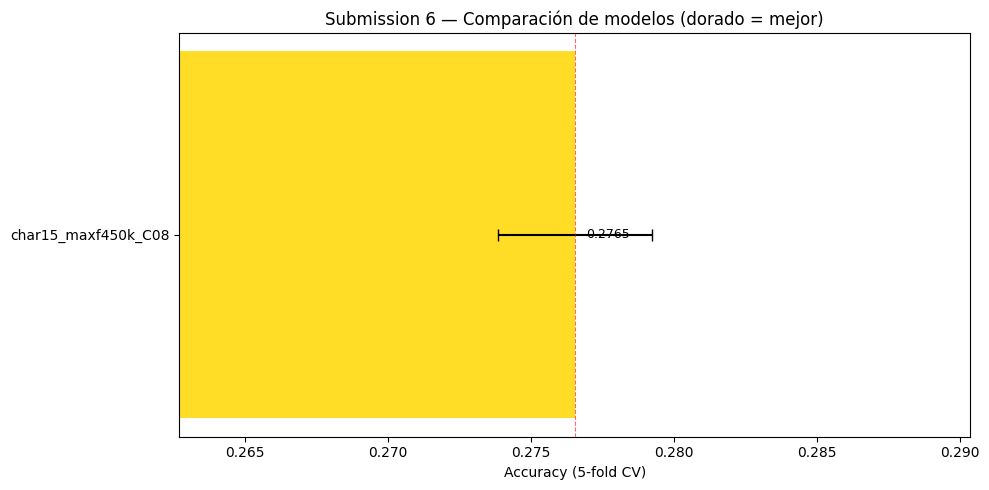

Mejor modelo: char15_maxf450k_C08


In [13]:
# ── Comparación visual ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
nombres = cv_results_s6['model'].tolist()
scores  = cv_results_s6['cv_accuracy_mean'].tolist()
stds    = cv_results_s6['cv_accuracy_std'].tolist()
mejor   = nombres[0]
colores = ['gold' if n == mejor else 'steelblue' for n in nombres]
bars    = ax.barh(nombres, scores, xerr=stds, color=colores,
                  alpha=0.85, capsize=4, height=0.5)
ax.axvline(scores[0], color='red', linestyle='--', linewidth=0.8, alpha=0.6)
for bar, s in zip(bars, scores):
    ax.text(s + 0.0004, bar.get_y() + bar.get_height()/2,
            f'{s:.4f}', va='center', fontsize=9)
rng = max(scores) - min(scores)
ax.set_xlim(min(scores) - rng*0.5, max(scores) + rng*0.3)
ax.set_xlabel('Accuracy (5-fold CV)')
ax.set_title('Submission 6 — Comparación de modelos (dorado = mejor)')
plt.tight_layout()
plt.show()
print(f'Mejor modelo: {mejor}')

In [ ]:
# ── Entrenamiento final y generación de submission ───────────────────────
best_name_s6  = cv_results_s6.loc[0, 'model']
best_model_s6 = models_s6[best_name_s6]

print(f'Entrenando [{best_name_s6}] con 100% de los datos...')
t0 = time.time()
best_model_s6.fit(x_train['text'].values, y_train)
print(f'Entrenamiento completado en {time.time()-t0:.0f}s')

# Guardar modelo
model_path_s6 = OUTPUT_DIR / 'modelo_submission_06.joblib'
joblib.dump(best_model_s6, model_path_s6)
print('Modelo guardado en:', model_path_s6)

# Generar predicciones para Kaggle
preds_s6 = best_model_s6.predict(x_eval['text'].values)
submission_s6 = pd.DataFrame({
    'id':     eval_ids,
    'answer': preds_s6.astype(int)
})
submission_path_s6 = OUTPUT_DIR / 'submission_06_word_char.csv'
submission_s6.to_csv(submission_path_s6, index=False)

print('Submission guardada en:', submission_path_s6)
print('Filas:', len(submission_s6))
display(submission_s6.head())

Entrenando [char15_maxf450k_C08] con 100% de los datos...
Entrenamiento completado en 139s
Modelo guardado en: C:\Users\juand\Downloads\Proyecto_ML\outputs_parte1\modelo_submission_06.joblib
Submission guardada en: C:\Users\juand\Downloads\Proyecto_ML\outputs_parte1\submission_06_word_char.csv
Filas: 3490


,id,answer
0,0,173
1,1,187
2,2,150
3,3,172
4,4,153
